In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set(style="whitegrid")
from pathlib import Path
import statsmodels.api as sm
import statsmodels.formula.api as smf
import math
from scipy.stats import linregress
import warnings
warnings.filterwarnings("ignore")

In [52]:
from data import health_df, weather_df, df_wide, extreme_df, H_KEYS, C_KEYS, urban_df, ECON_KEYS, CLIMATE_VARS, var_directions, metrics, pct_high, pct_low

# Climate trends

In [ ]:
# CLIMATE_VARS = {
#     "Temperature / Heat": [
#         "mean_temp", "max_temp", "anomaly_heat_days",
#         "heat_episodes", "extreme_heat_episodes",
#         "extreme_area", "caution_area",
#         "mean_caution_area", "mean_extreme_area",
#         "max_heat_intensity", "max_rolling_heat_stress",
#         "total_tropical_nights"
#     ],

#     "Cold / Freeze": [
#         "anomaly_cold_days", "annual_freeze_burden",
#         "min_temp", "winter_mean_snow_density",
#         "mean_cold_area"
#     ],

#     "Air Pollution": [
#         "pm25_mean", "ozone_mean", "no2_mean"
#     ],

#     "Precipitation / Drought": [
#         "heavy_rain_days", "extreme_rain_days",
#         "max_year_precip", "annual_dry_area",
#         "drought_episodes", "mean_dry_area",
#         "evap_deficit"
#     ],

#     "Runoff / Flood": [
#         "runoff_days", "max_runoff"
#     ],

#     "Wind / Pressure": [
#         "max_monthly_wind_speed", "mean_annual_wind_speed",
#         "pressure_variability"
#     ],

#     "Soil / Moisture": [
#         "mean_soil_moisture", "min_monthly_soil_moisture",
#         "annual_total_evap", "annual_potential_evap"
#     ],

#     "Energy Fluxes": [
#         "mean_annual_net_solar", "mean_annual_net_thermal",
#         "mean_latent_heat", "mean_sensible_heat"
#     ],
# }

In [46]:
exclude_cols = ['country', 'year']
climate_vars = [c for c in weather_df.columns if c not in exclude_cols]
len(climate_vars)

43

In [28]:
def compute_group_index(df, groups):
    df_out = df.copy()
    
    for name, cols in groups.items():
        valid_cols = [c for c in cols if c in df.columns]
        df_out[name + "_index"] = df[valid_cols].mean(axis=1)
    
    return df_out

weather_idx = compute_group_index(weather_df, CLIMATE_VARS)

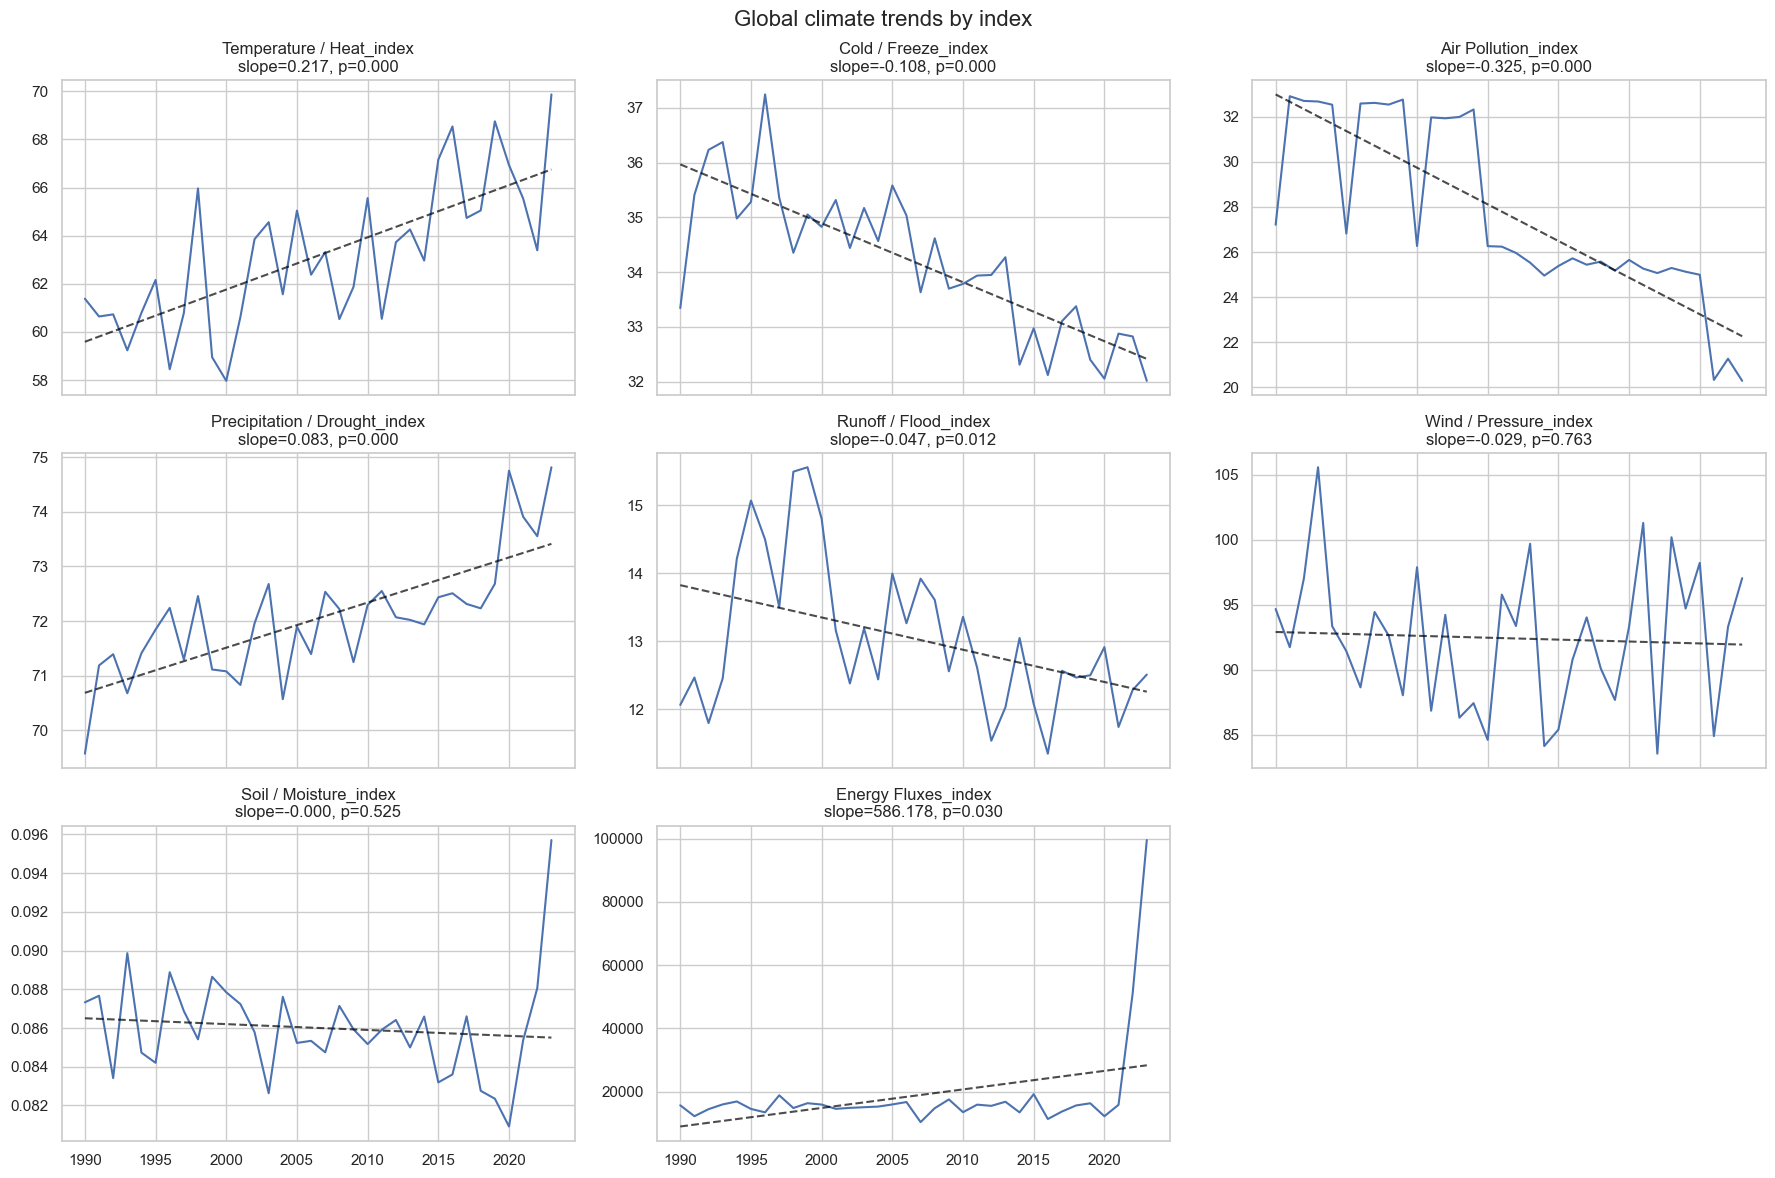

In [29]:
global_idx = weather_idx.groupby("year").mean(numeric_only=True).reset_index()

cols = [c for c in global_idx.columns if "_index" in c]

n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows), sharex=True)
axes = axes.flatten()

def add_trend(ax, x, y):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    ax.plot(x, model.predict(X), linestyle="--", color="black", alpha=0.7)
    return model.params[1], model.pvalues[1]

for i, col in enumerate(cols):
    ax = axes[i]
    
    x = global_idx["year"]
    y = global_idx[col]
    
    sns.lineplot(x=x, y=y, ax=ax)
    
    slope, pval = add_trend(ax, x, y)
    
    ax.set_title(f"{col}\nslope={slope:.3f}, p={pval:.3f}")
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Global climate trends by index", fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import statsmodels.api as sm

def get_apc(y):
    y = y.replace(0, np.nan).dropna()
    
    if len(y) < 5 or y.nunique() <= 1:
        return np.nan, np.nan
    
    x = np.arange(len(y))
    X = sm.add_constant(x)
    
    model = sm.OLS(np.log(y), X).fit()
    
    beta = model.params[1]
    pval = model.pvalues[1]
    
    apc = (np.exp(beta) - 1) * 100
    
    return apc, pval

results = []

for country, g in weather_df.groupby("country"):
    g = g.sort_values("year")
    
    apc, pval = get_apc(g["mean_temp"])
    
    results.append({
        "country": country,
        "apc_temp": apc,
        "pval": pval
    })

apc_df = pd.DataFrame(results)

In [34]:
all_results = []

for col in [c for c in weather_idx.columns if "_index" in c]:
    for country, g in weather_idx.groupby("country"):
        g = g.sort_values("year")
        
        apc, pval = get_apc(g[col])
        
        all_results.append({
            "country": country,
            "variable": col,
            "apc": apc,
            "pval": pval
        })

apc_all = pd.DataFrame(all_results)

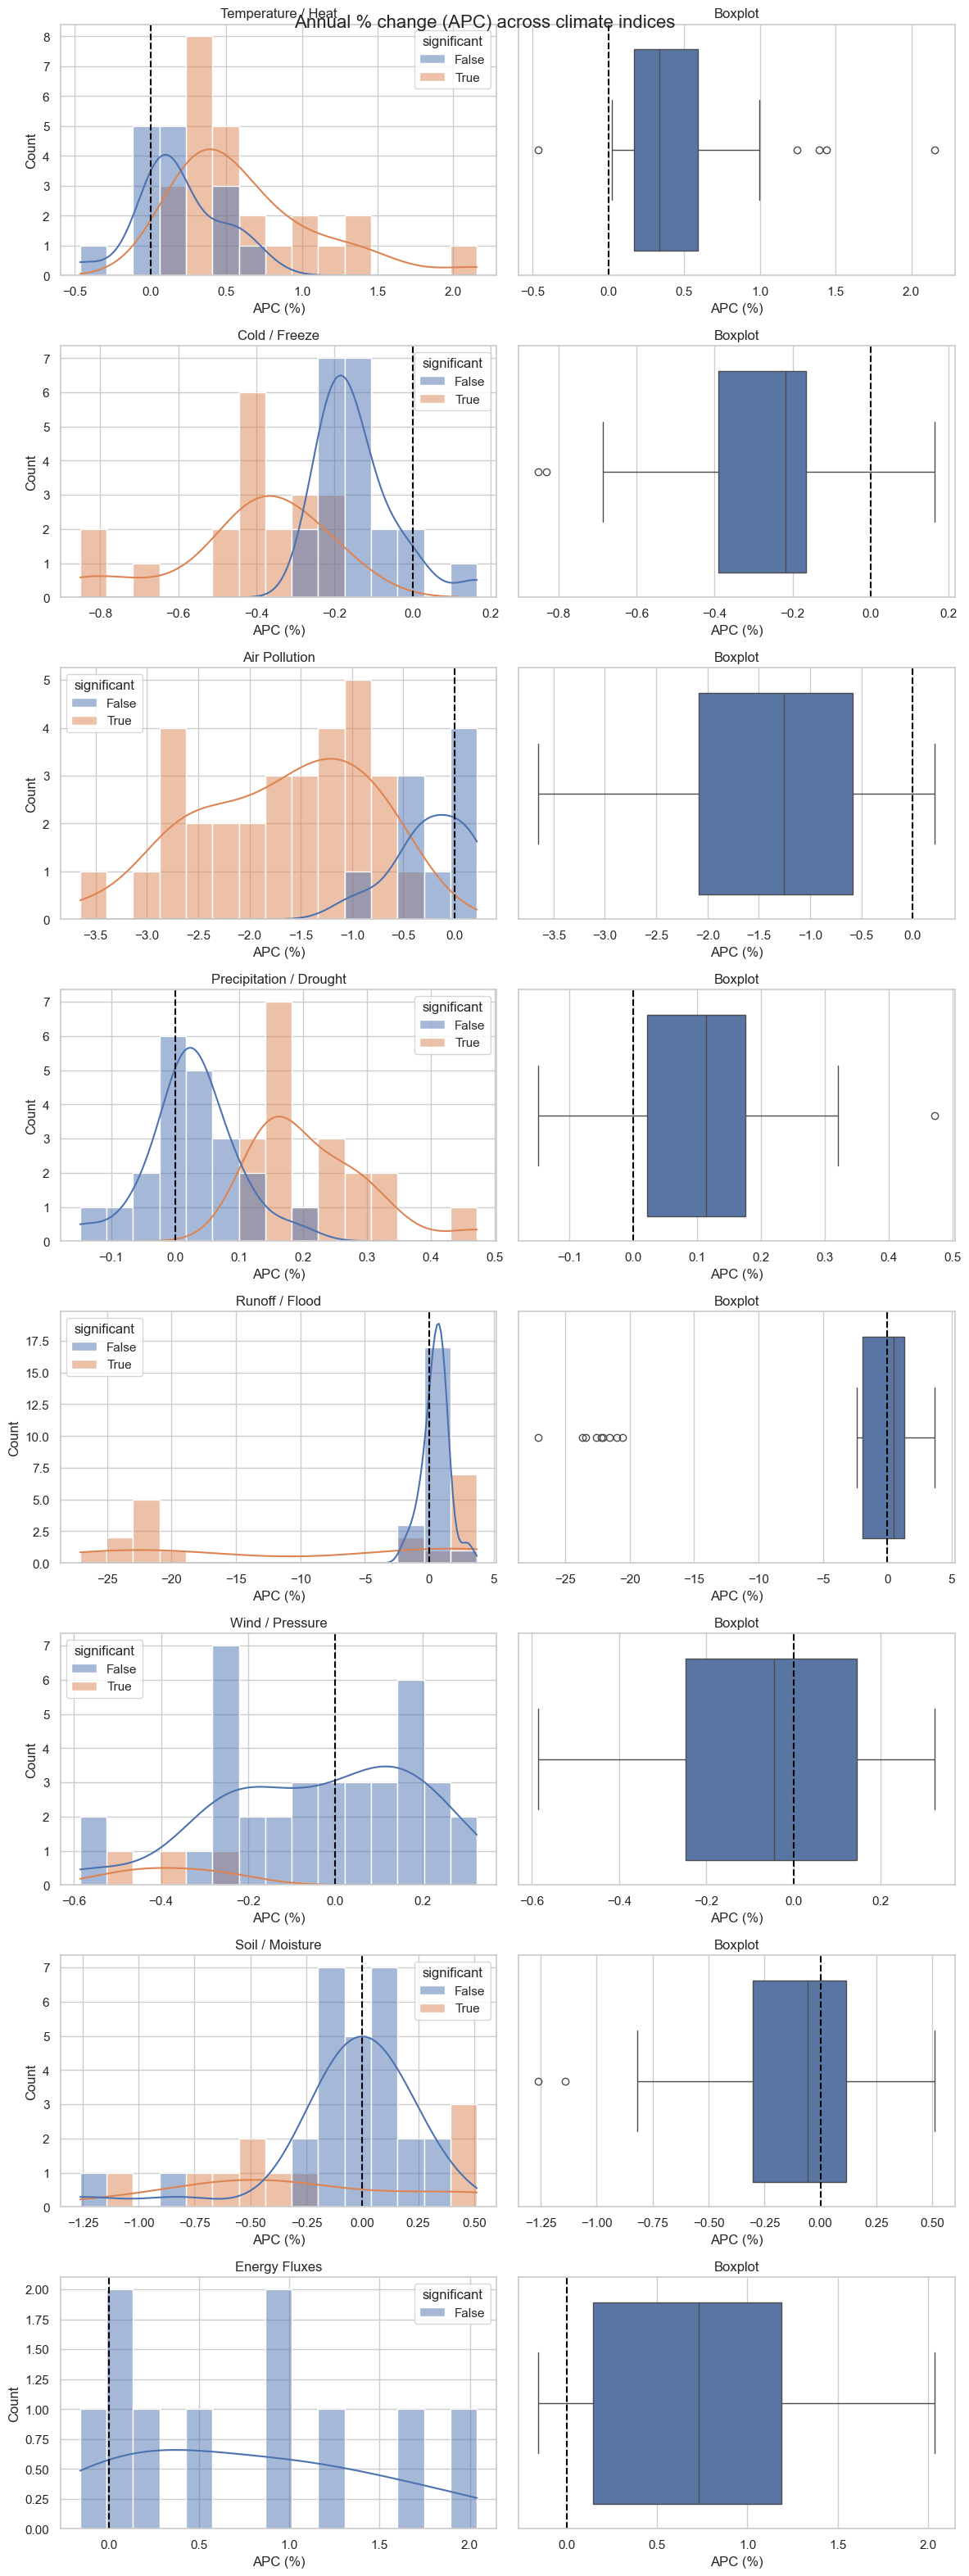

In [ ]:
variables = apc_all["variable"].unique()
n = len(variables)
fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))

for i, var in enumerate(variables):
    df_v = apc_all[apc_all["variable"] == var].copy()
    df_v["significant"] = df_v["pval"] < 0.05

    ax1 = axes[i, 0]
    sns.histplot(
        data=df_v,
        x="apc",
        hue="significant",
        kde=True,
        ax=ax1,
        bins=15
    )
    ax1.axvline(0, color="black", linestyle="--")
    ax1.set_title(var.replace("_index", ""))
    ax1.set_xlabel("APC (%)")
    ax2 = axes[i, 1]
    sns.boxplot(x=df_v["apc"], ax=ax2)
    ax2.axvline(0, color="black", linestyle="--")
    ax2.set_title("Boxplot")
    ax2.set_xlabel("APC (%)")

plt.suptitle("Annual % change (APC) across climate indices", fontsize=16)
plt.tight_layout()
plt.show()

Heat / Temperature → steady increase (positive APC in most countries)\
Cold indicators → decrease (fewer cold extremes)\
Air pollution → overall decrease, but with wide variation\
Precipitation / Drought → weak positive trend, high variability\
Runoff / Flood → unstable, with significant outliers\
Wind / Pressure, Soil, Energy fluxes  → no clear global trend

# Extreme years

In [45]:
pct_high = 95
pct_low  = 5
extremes_plots_dir = Path("../results/trend_plots/extremes_plots")
extremes_dir = Path("../results/trends/extremes")

Let's define percentiles for each variable.

In [53]:
records = []
for country, grp in weather_df.groupby("country"):
    for var, direction in var_directions.items():
        if var not in grp.columns:
            continue
        series = grp[var].dropna()
        if len(series) < 5:
            continue
        records.append({
            "country":      country,
            "variable":     var,
            "direction":    direction,
            "thresh_high":  np.percentile(series, pct_high),
            "thresh_low":   np.percentile(series, pct_low),
            "mean":         series.mean(),
            "std":          series.std(),
            "n_obs":        len(series),
        })
if not records:
    percentiles = pd.DataFrame()
else:
    percentiles = pd.DataFrame(records).set_index(["country", "variable"])

Now detect extreme years

In [99]:
if percentiles.empty:
    extreme_df = pd.DataFrame()
else:
    rows = []
    for (country, var), thresholds in percentiles.iterrows():

        subset = (weather_df[weather_df["country"] == country][["year", var]]
                    .dropna()
                    .copy())
        if subset.empty:
            continue

        for _, row in subset.iterrows():
            val  = row[var]
            year = int(row["year"])

            is_extreme_high = (val >= thresholds["thresh_high"]) and (thresholds["direction"] in ("HIGH", "BOTH"))
            is_extreme_low  = (val <= thresholds["thresh_low"])  and (thresholds["direction"] in ("LOW",  "BOTH"))
            is_extreme = is_extreme_high or is_extreme_low

            if is_extreme_high:
                direction = "HIGH"
            elif is_extreme_low:
                direction = "LOW"
            else:
                direction = "normal"

            rows.append({
                "country":              country,
                "year":                 year,
                "variable":             var,
                "all_time_mean":        thresholds["mean"],
                "all_time_std":         thresholds["std"],
                "thresh_high":          thresholds["thresh_high"],
                "thresh_low":           thresholds["thresh_low"],
                "value":                val,
                "semantic_direction":   thresholds["direction"],
                "deviation_from_mean":  val - thresholds["mean"],
                "z_score":              (val - thresholds["mean"]) / thresholds["std"] if thresholds["std"] > 0 else 0.0,
                "direction":            direction,
                "is_extreme":           is_extreme,
            })
    extreme_df = pd.DataFrame(rows) if rows else pd.DataFrame()
extreme_df.to_csv("../DATA/extreme_df.csv", index=False)
extreme_df

,country,year,variable,all_time_mean,all_time_std,thresh_high,thresh_low,value,semantic_direction,deviation_from_mean,z_score,direction,is_extreme
0,Algeria,1990,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.301906e+01,BOTH,-1.134109e-01,-0.193669,normal,False
1,Algeria,1991,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.202705e+01,BOTH,-1.105420e+00,-1.887694,LOW,True
2,Algeria,1992,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.168704e+01,BOTH,-1.445428e+00,-2.468316,LOW,True
3,Algeria,1993,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.244701e+01,BOTH,-6.854540e-01,-1.170530,normal,False
4,Algeria,1994,mean_temp,2.313247e+01,0.585593,2.415013e+01,2.230003e+01,2.261556e+01,BOTH,-5.169040e-01,-0.882702,normal,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49604,Zimbabwe,2019,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-5.679308e+06,BOTH,-5.553542e+05,-0.803938,normal,False
49605,Zimbabwe,2020,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-5.377792e+06,BOTH,-2.538372e+05,-0.367458,normal,False
49606,Zimbabwe,2021,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-4.770314e+06,BOTH,3.536403e+05,0.511934,normal,False
49607,Zimbabwe,2022,mean_sensible_heat,-5.123954e+06,690792.329506,-3.926852e+06,-6.065004e+06,-3.888645e+06,BOTH,1.235309e+06,1.788250,HIGH,True


In [55]:
only_extreme = extreme_df[extreme_df["is_extreme"]].copy()
def vars_for_direction(subdf, dir_label):
    return ", ".join(subdf.loc[subdf["direction"] == dir_label, "variable"].tolist())

records = []
for (country, year), grp in only_extreme.groupby(["country", "year"]):
    records.append({
        "country":            country,
        "year":               int(year),
        "n_extreme_vars":     len(grp),
        "max_z_score":        grp["z_score"].abs().max(),
        "extreme_high_vars":  vars_for_direction(grp, "HIGH"),
        "extreme_low_vars":   vars_for_direction(grp, "LOW"),
    })

agg = pd.DataFrame(records)
agg["extreme_high_count"] = agg["extreme_high_vars"].apply(
    lambda s: len(s.split(", ")) if s else 0)
agg["extreme_low_count"]  = agg["extreme_low_vars"].apply(
    lambda s: len(s.split(", ")) if s else 0)

extreme_years_table = agg.sort_values(["country", "year"]).reset_index(drop=True)
extreme_years_table.to_csv(extremes_dir / "extreme_years_table.csv", index=False)
extreme_years_table

,country,year,n_extreme_vars,max_z_score,extreme_high_vars,extreme_low_vars,extreme_high_count,extreme_low_count
0,Algeria,1990,1,2.050032,max_runoff,,1,0
1,Algeria,1991,1,1.887694,,mean_temp,0,1
2,Algeria,1992,2,2.468316,extreme_rain_days,mean_temp,1,1
3,Algeria,1993,1,1.173821,pressure_variability,,1,0
4,Algeria,1994,1,1.757705,,min_monthly_soil_moisture,0,1
...,...,...,...,...,...,...,...,...
1168,Zimbabwe,2019,8,3.658916,"mean_temp, max_temp, anomaly_heat_days, heat_e...",,8,0
1169,Zimbabwe,2020,4,1.807117,"winter_mean_snow_density, extreme_rain_days, n...",,4,0
1170,Zimbabwe,2021,3,1.621221,"winter_mean_snow_density, pressure_variability...",,3,0
1171,Zimbabwe,2022,6,1.945156,"winter_mean_snow_density, annual_potential_eva...",mean_annual_net_solar,5,1


One row per (country, year, cause) with:

- Extreme year flag + which vars were extreme this year and 3 previous

- Health outcome deviations from long-term average

Robust to empty extreme_years_table.

In [56]:
extreme_base = extreme_years_table[
    ["country", "year", "n_extreme_vars", "max_z_score", "extreme_high_vars", "extreme_low_vars"]
].copy()
extreme_base["is_extreme_year"] = True

lagged_dfs = [extreme_base]
for lag in [1, 2, 3]:
    lag_df = extreme_base.copy()
    lag_df["year"] = lag_df["year"] + lag

    lag_df = lag_df.rename(columns={
        "is_extreme_year": f"is_extreme_year_lag{lag}",
        "n_extreme_vars": f"n_extreme_vars_lag{lag}",
        "max_z_score": f"max_z_score_lag{lag}",
        "extreme_high_vars": f"extreme_high_vars_lag{lag}",
        "extreme_low_vars": f"extreme_low_vars_lag{lag}"
    })
    lagged_dfs.append(lag_df)

health_dev_df = health_df.copy()

for l_df in lagged_dfs:
    health_dev_df = health_dev_df.merge(l_df, on=["country", "year"], how="left")

long_means = (health_df
                .groupby(["country", "cause"])[metrics]
                .mean()
                .rename(columns={m: f"{m}_ltmean" for m in metrics})
                .reset_index())

health_dev_df = health_dev_df.merge(long_means, on=["country", "cause"], how="left")

for m in metrics:
    health_dev_df[f"{m}_dev_abs"] = health_dev_df[m] - health_dev_df[f"{m}_ltmean"]
    health_dev_df[f"{m}_dev_pct"] = (
        (health_dev_df[m] - health_dev_df[f"{m}_ltmean"]) / 
        health_dev_df[f"{m}_ltmean"].replace(0, np.nan)
    ) * 100

lag_cols = []
for lag in [1, 2, 3]:
    lag_cols.extend([f"is_extreme_year_lag{lag}", f"n_extreme_vars_lag{lag}", 
                     f"extreme_high_vars_lag{lag}", f"extreme_low_vars_lag{lag}"])

for col in health_dev_df.columns:
    if "is_extreme_year" in col:
        health_dev_df[col] = health_dev_df[col].fillna(False)
    elif "vars" in col:
        health_dev_df[col] = health_dev_df[col].fillna("")
    elif "n_extreme" in col:
        health_dev_df[col] = health_dev_df[col].fillna(0).astype(int)

keep_cols = (
    ["country", "year", "cause", "income_level_mode"]
    + metrics
    + [f"{m}_ltmean" for m in metrics]
    + [f"{m}_dev_pct" for m in metrics]
    + ["is_extreme_year", "n_extreme_vars", "extreme_high_vars", "extreme_low_vars"]
    + lag_cols
)

final_table = (
    health_dev_df[[c for c in keep_cols if c in health_dev_df.columns]]
    .sort_values(["country", "year", "cause"])
    .reset_index(drop=True)
)

final_table.to_csv(extremes_dir / "health_deviation_full_lags.csv", index=False)
final_table

,country,year,cause,income_level_mode,Deaths,DALYs,Incidence,Deaths_ltmean,DALYs_ltmean,Incidence_ltmean,...,extreme_high_vars_lag1,extreme_low_vars_lag1,is_extreme_year_lag2,n_extreme_vars_lag2,extreme_high_vars_lag2,extreme_low_vars_lag2,is_extreme_year_lag3,n_extreme_vars_lag3,extreme_high_vars_lag3,extreme_low_vars_lag3
0,Algeria,1990,Cardiovascular diseases,LM,531.784337,11253.922792,796.963385,413.881651,8624.384166,704.075784,...,,,False,,,,False,,,
1,Algeria,1990,Chronic respiratory diseases,LM,36.091579,1002.651708,900.811251,30.394363,904.603461,935.449891,...,,,False,,,,False,,,
2,Algeria,1990,Environmental heat and cold exposure,LM,0.136969,10.462595,34.391902,0.095447,7.876651,31.683433,...,,,False,,,,False,,,
3,Algeria,1991,Cardiovascular diseases,LM,522.176614,11022.731268,795.362271,413.881651,8624.384166,704.075784,...,max_runoff,,False,,,,False,,,
4,Algeria,1991,Chronic respiratory diseases,LM,34.965694,986.116056,905.463163,30.394363,904.603461,935.449891,...,max_runoff,,False,,,,False,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,Zimbabwe,2022,Chronic respiratory diseases,L,38.466502,1230.229784,919.188052,42.353562,1290.613082,875.909198,...,"winter_mean_snow_density, pressure_variability...",,True,4.0,"winter_mean_snow_density, extreme_rain_days, n...",,True,8.0,"mean_temp, max_temp, anomaly_heat_days, heat_e...",
4076,Zimbabwe,2022,Environmental heat and cold exposure,L,0.475543,28.093528,34.143777,0.538626,29.821435,34.405821,...,"winter_mean_snow_density, pressure_variability...",,True,4.0,"winter_mean_snow_density, extreme_rain_days, n...",,True,8.0,"mean_temp, max_temp, anomaly_heat_days, heat_e...",
4077,Zimbabwe,2023,Cardiovascular diseases,L,188.578239,4836.188801,619.062979,221.129624,5454.801948,614.196451,...,"winter_mean_snow_density, annual_potential_eva...",mean_annual_net_solar,True,3.0,"winter_mean_snow_density, pressure_variability...",,True,4.0,"winter_mean_snow_density, extreme_rain_days, n...",
4078,Zimbabwe,2023,Chronic respiratory diseases,L,39.360147,1244.591131,920.774991,42.353562,1290.613082,875.909198,...,"winter_mean_snow_density, annual_potential_eva...",mean_annual_net_solar,True,3.0,"winter_mean_snow_density, pressure_variability...",,True,4.0,"winter_mean_snow_density, extreme_rain_days, n...",


## Visualization

In [58]:
RED   = "#c0392b"
BLUE  = "#2471a3"
GOLD  = "#d68910"
GRAY  = "#7a7570"
WHITE = "#cccccc"
BLACK = "#0f0e0c"
PURPLE = "#7d3c98"
GREEN = "#1e8449"
ORANGE = "#ff9524"

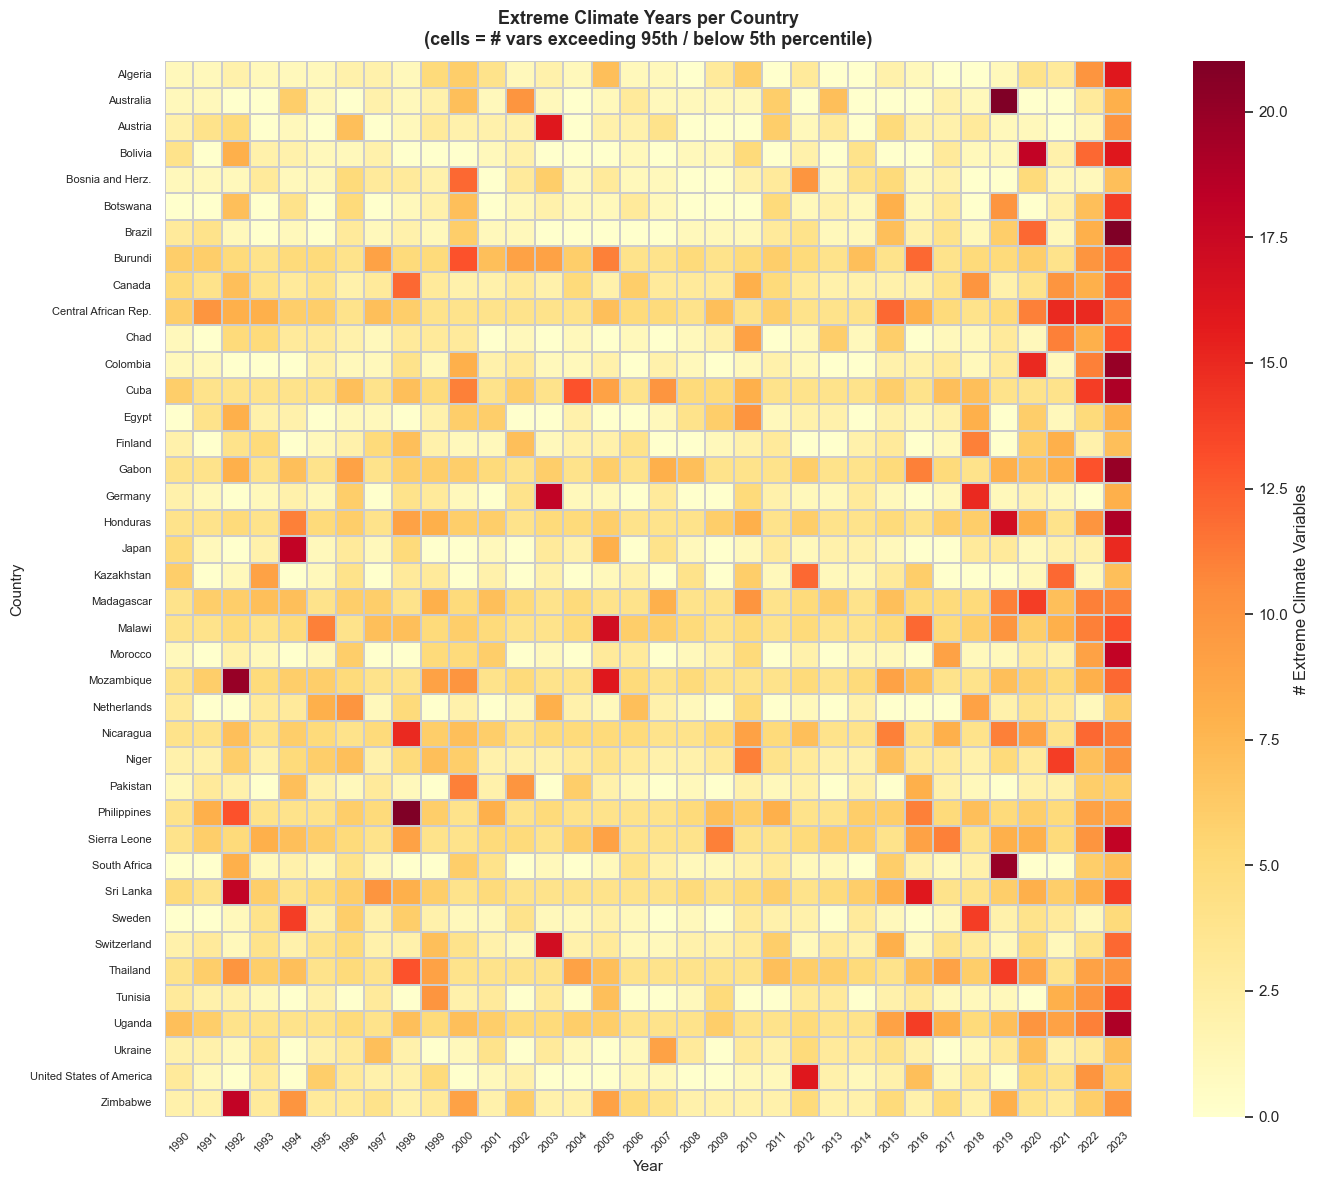

In [60]:
pivot = (extreme_df[extreme_df["is_extreme"]]
            .groupby(["country", "year"])["variable"]
            .count()
            .unstack(fill_value=0))
pivot = pivot.sort_index() 
dynamic_height = max(8, len(pivot) * 0.2) 
fig, ax = plt.subplots(figsize=(max(14, len(pivot.columns) * 0.4),
                                    max(8, 40 * 0.3)))
cmap = plt.cm.YlOrRd
sns.heatmap(pivot, cmap=cmap, ax=ax, linewidths=0.3, linecolor= WHITE,
            cbar_kws={"label": "# Extreme Climate Variables"})
ax.set_title(f"Extreme Climate Years per Country\n"
                f"(cells = # vars exceeding {pct_high}th / below {pct_low}th percentile)",
                fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Country", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(extremes_plots_dir/"extremes_by_country.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

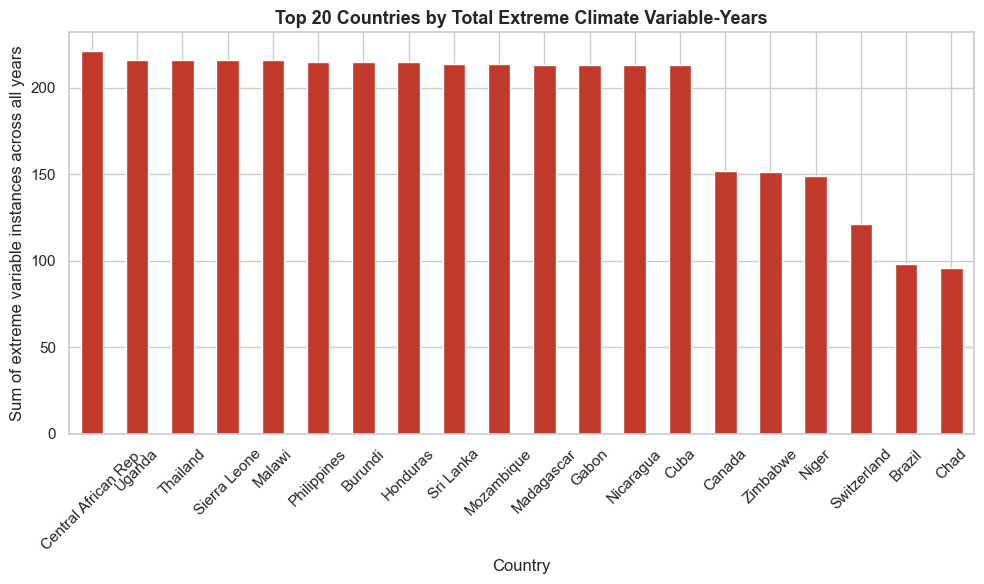

In [61]:
country_counts = (extreme_years_table
                    .groupby("country")["n_extreme_vars"]
                    .sum()
                    .sort_values(ascending=False)
                    .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
country_counts.plot(kind="bar", ax=ax, color=RED, edgecolor="white")
ax.set_title(f"Top {20} Countries by Total Extreme Climate Variable-Years",
                fontsize=13, fontweight="bold")
ax.set_xlabel("Country")
ax.set_ylabel("Sum of extreme variable instances across all years")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(extremes_plots_dir/"top_extreme_countries.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

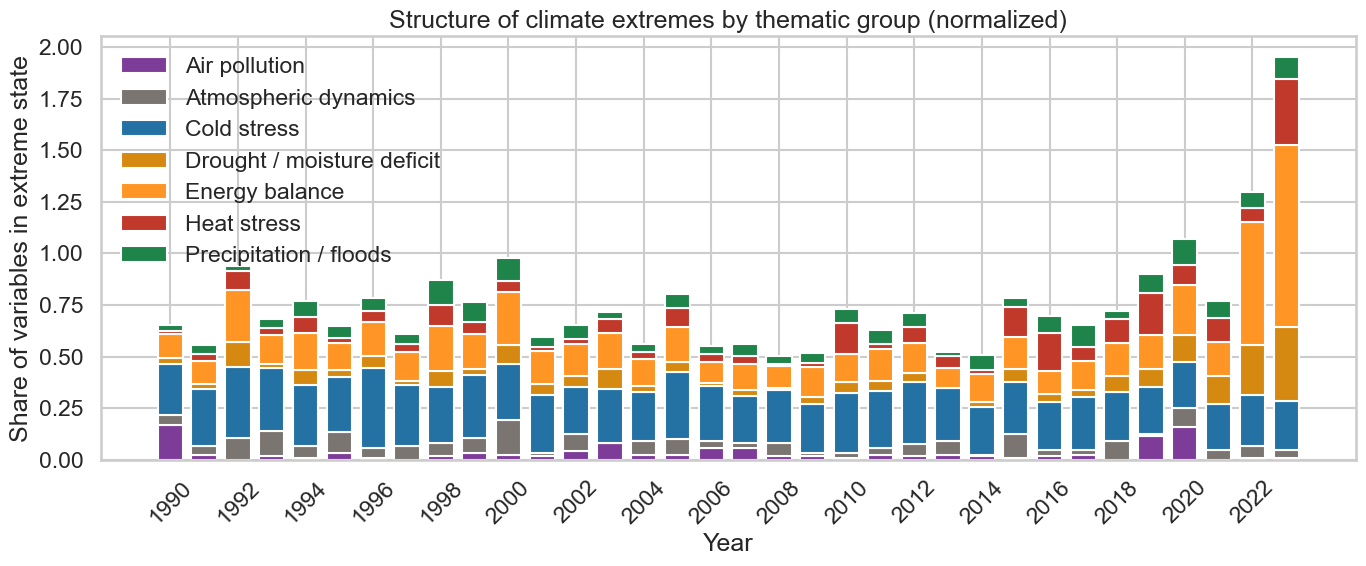

In [95]:
# Heat stress
HEAT_VARS = {
    "mean_temp", "max_temp", "anomaly_heat_days", "heat_episodes", "extreme_heat_episodes",
    "extreme_area", "caution_area", "mean_caution_area", "mean_extreme_area"
}
# Cold stress
COLD_VARS = {
    "anomaly_cold_days", "annual_freeze_burden", "min_temp", "winter_mean_snow_density", "mean_cold_area"
}
# Precipitation / runoff / floods
PRECIP_VARS = {
    "heavy_rain_days", "extreme_rain_days", "max_year_precip", "runoff_days", "max_runoff"
}
# Drought / moisture deficit
DROUGHT_VARS = {
    "annual_dry_area", "drought_episodes", "mean_dry_area", "evap_deficit", "mean_soil_moisture",
    "min_monthly_soil_moisture", "annual_potential_evap", "annual_total_evap"
}
# Air pollution
AIR_VARS = {
    "pm2.5_mean", "ozone_mean", "no2_mean"
}
# Atmospheric dynamics (wind + pressure)
ATMOS_VARS = {
    "max_monthly_wind_speed", "mean_annual_wind_speed", "pressure_variability"
}
# Energy balance / radiation / heat fluxes
ENERGY_VARS = {
    "mean_annual_net_solar", "mean_annual_net_thermal", "mean_latent_heat",
    "mean_sensible_heat", "mean_annual_rsn"
}

GROUPS = {
    "Heat stress": HEAT_VARS, "Cold stress": COLD_VARS, "Precipitation / floods": PRECIP_VARS,
    "Drought / moisture deficit": DROUGHT_VARS, "Air pollution": AIR_VARS,
    "Atmospheric dynamics": ATMOS_VARS, "Energy balance": ENERGY_VARS
}
years_all = sorted(extreme_df["year"].unique())
records = []

for name, vars_set in GROUPS.items():
    sub = extreme_df[extreme_df["variable"].isin(vars_set)]
    sub = sub[sub["is_extreme"]]
    counts = sub.groupby("year").size()
    n_vars = len(vars_set)
    for y in years_all:
        extreme_obs = counts.get(y, 0)
        rate = extreme_obs / (40 * n_vars)
        records.append({
            "year": y,
            "group": name,
            "rate": rate
        })

group_year = pd.DataFrame(records)
pivot = group_year.pivot(index="year", columns="group", values="rate").fillna(0)

fig, ax = plt.subplots(figsize=(14,6))
bottom = np.zeros(len(pivot))
colors = {
    "Heat stress": RED,
    "Cold stress": BLUE,
    "Drought / moisture deficit": GOLD,
    "Air pollution": PURPLE,
    "Precipitation / floods": GREEN,
    "Atmospheric dynamics": GRAY,
    "Energy balance": ORANGE
}

for g in pivot.columns:
    ax.bar(
        pivot.index,
        pivot[g],
        bottom=bottom,
        label=g,
        color=colors[g],
        width=0.75
    )
    bottom += pivot[g].values

ax.set_ylabel("Share of variables in extreme state")
ax.set_xlabel("Year")
ax.set_title("Structure of climate extremes by thematic group (normalized)")
ax.legend(loc="upper left")
ax.set_xticks(years_all[::2])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
# plt.savefig(extremes_plots_dir/"extremes_structure.png", dpi=150, bbox_inches="tight")
plt.show()

In [75]:
from scipy.stats import ttest_ind
def analyze_extreme_impact_fixed(df_final):
    df = df_final.copy()
    def tw_demean(group):
        return group - group.mean()

    df['DALYs_dm_fixed'] = df.groupby(['cause', 'country'])['DALYs'].transform(lambda x: x - x.mean())
    df['DALYs_dm_fixed'] = df.groupby(['cause', 'year'])['DALYs_dm_fixed'].transform(lambda x: x - x.mean())

    results = []
    for cause in df['cause'].unique():
        subset = df[df['cause'] == cause]

        ext_lag = subset[subset['is_extreme_year_lag1'] == True]['DALYs_dm_fixed'].dropna()
        normal = subset[subset['is_extreme_year_lag1'] == False]['DALYs_dm_fixed'].dropna()
        
        if len(ext_lag) > 5:
            t_stat, p_val = ttest_ind(ext_lag, normal)
            results.append({
                'Cause': cause,
                'Extreme_Lag1_Mean': ext_lag.mean(),
                'Normal_Lag1_Mean': normal.mean(),
                'P_value': p_val
            })
    return pd.DataFrame(results)

fixed_stats = analyze_extreme_impact_fixed(final_table)
print(fixed_stats)

                                  Cause  Extreme_Lag1_Mean  Normal_Lag1_Mean  \
0               Cardiovascular diseases          -2.673968         13.346280   
1          Chronic respiratory diseases          -0.392632          1.959700   
2  Environmental heat and cold exposure          -0.394260          1.967824   

    P_value  
0  0.760443  
1  0.779360  
2  0.273372  


Cardiovascular diseases -0.1237476663211618 4.717035844773219e-06
Chronic respiratory diseases -0.11987118455207217 9.312196081671345e-06
Environmental heat and cold exposure -0.03280454859160542 0.22666862194207513


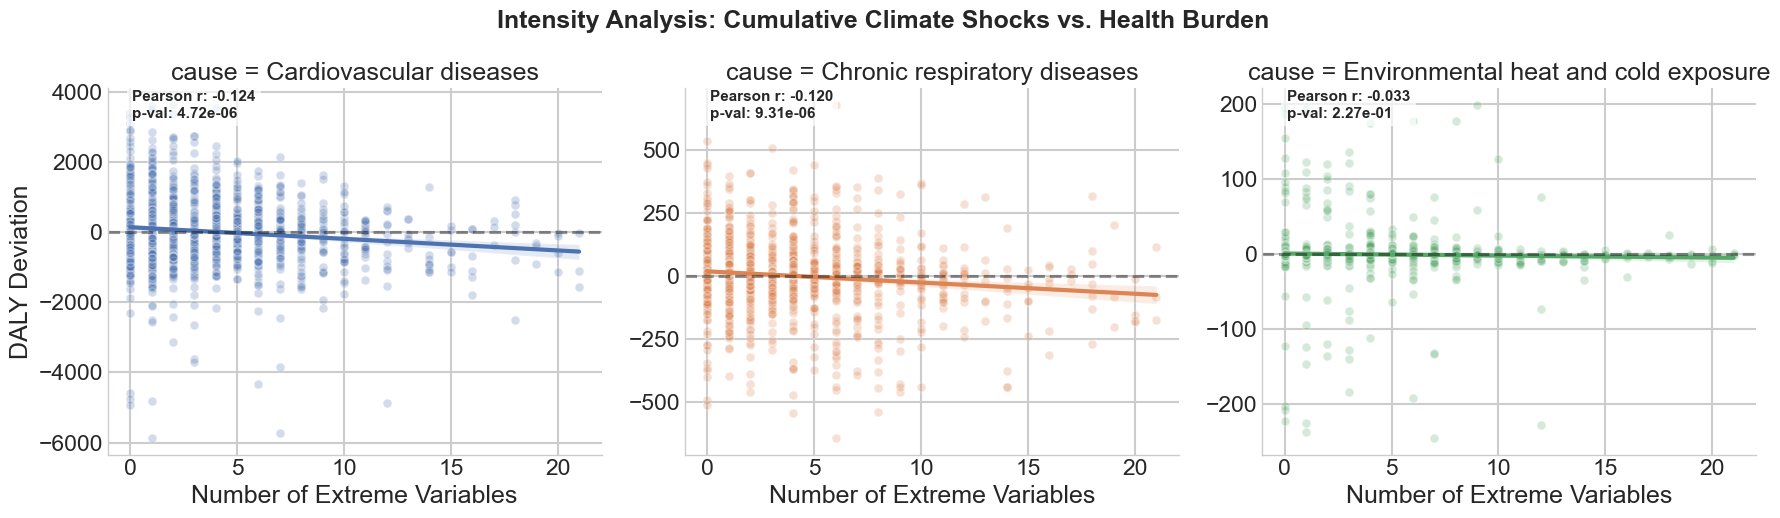

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def run_extreme_intensity_step_b(df, output_file="extreme_intensity_analysis.png"):
    # --- ОЧИЩЕННЯ ДАНИХ (вирішує ValueError) ---
    # 1. Створюємо копію, щоб не псувати основну таблицю
    df_clean = df.copy()
    
    # 2. Перетворюємо n_extreme_vars на числа, замінюючи помилки/порожнечі на 0
    df_clean['n_extreme_vars'] = pd.to_numeric(df_clean['n_extreme_vars'], errors='coerce').fillna(0)
    
    # 3. Розрахунок DALYs_dm (якщо ще немає)
    if 'DALYs_dm' not in df_clean.columns:
        df_clean['DALYs_dm'] = df_clean.groupby(['country', 'cause'])['DALYs'].transform(lambda x: x - x.mean())
    
    # 4. Перетворюємо DALYs_dm на числа та видаляємо NaN
    df_clean['DALYs_dm'] = pd.to_numeric(df_clean['DALYs_dm'], errors='coerce')
    df_clean = df_clean.dropna(subset=['n_extreme_vars', 'DALYs_dm', 'cause'])

    # --- ВІЗУАЛІЗАЦІЯ ---
    sns.set_context("talk")
    try:
        plt.style.use('seaborn-v0_8-whitegrid')
    except:
        sns.set_style("whitegrid")

    # Побудова графіку
    g = sns.lmplot(
        data=df_clean, 
        x='n_extreme_vars', 
        y='DALYs_dm', 
        hue='cause', 
        col='cause', 
        col_wrap=3,
        height=5, 
        aspect=1.2,
        scatter_kws={'alpha': 0.25, 's': 40, 'edgecolor': 'w'},
        line_kws={'lw': 3},
        facet_kws={'sharey': False, 'sharex': True}
    )

    # Статистика
    for ax, (cause_name, subset) in zip(g.axes.flat, df_clean.groupby('cause')):
        valid = subset[['n_extreme_vars', 'DALYs_dm']].dropna()
        if len(valid) > 2:
            r, p = stats.pearsonr(valid['n_extreme_vars'], valid['DALYs_dm'])
            print(cause_name, r, p)
            ax.text(0.05, 0.92, f'Pearson r: {r:.3f}\np-val: {p:.2e}', 
                    transform=ax.transAxes, fontsize=11, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
            ax.axhline(0, color='black', linestyle='--', alpha=0.4)

    g.set_axis_labels("Number of Extreme Variables", "DALY Deviation")
    g.fig.suptitle("Intensity Analysis: Cumulative Climate Shocks vs. Health Burden", 
                   y=1.05, fontsize=18, fontweight='bold')
    
    plt.show()

# Запуск аналізу
run_extreme_intensity_step_b(final_table)

More extreme variables are not associated with a higher number of DALYs, but rather the opposite, цhich is quite surprising. Let's check if it is consistent between periods.

Cardiovascular diseases 1990-2006 -0.24778953154049033 5.672500017723365e-11
Cardiovascular diseases 2007-2023 0.04968666813375304 0.1956359257441319
Chronic respiratory diseases 1990-2006 -0.04017634784113988 0.29548444726741907
Chronic respiratory diseases 2007-2023 -0.11080208746393143 0.0038162806383510517
Environmental heat and cold exposure 1990-2006 -0.07602376740918897 0.04751523183286184
Environmental heat and cold exposure 2007-2023 0.036636030369177 0.34012748375795554


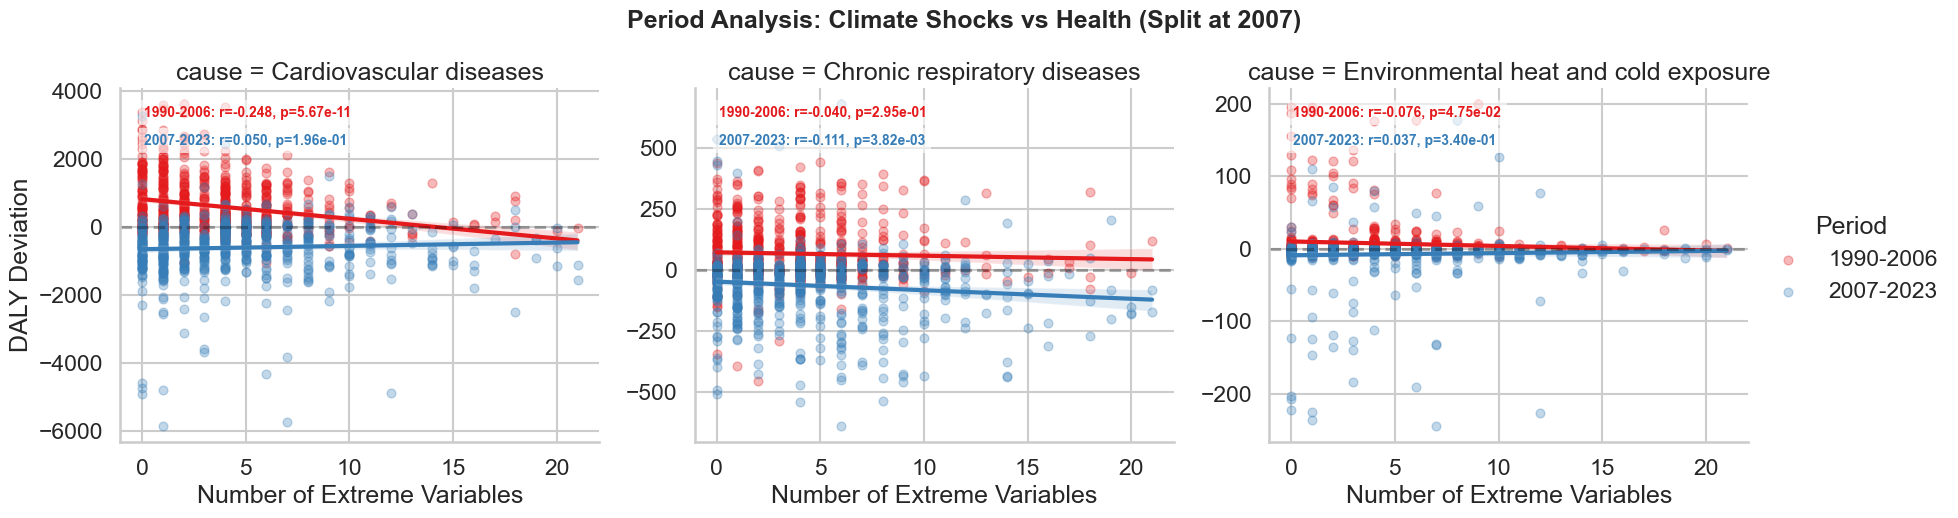

In [92]:
def run_extreme_intensity_by_periods(df, split_year=2007):
    df_clean = df.copy()
    
    df_clean['n_extreme_vars'] = pd.to_numeric(df_clean['n_extreme_vars'], errors='coerce').fillna(0)
    if 'DALYs_dm' not in df_clean.columns:
        df_clean['DALYs_dm'] = df_clean.groupby(['country', 'cause'])['DALYs'].transform(lambda x: x - x.mean())
    
    df_clean['DALYs_dm'] = pd.to_numeric(df_clean['DALYs_dm'], errors='coerce')
    df_clean = df_clean.dropna(subset=['n_extreme_vars', 'DALYs_dm', 'cause', 'year'])
    df_clean['Period'] = df_clean['year'].apply(lambda x: f'1990-{split_year-1}' if x < split_year else f'{split_year}-2023')
    sns.set_context("talk")
    g = sns.lmplot(
        data=df_clean, 
        x='n_extreme_vars', 
        y='DALYs_dm', 
        hue='Period',
        col='cause', 
        col_wrap=3,
        height=5, 
        aspect=1.2,
        palette='Set1',
        scatter_kws={'alpha': 0.3, 's': 40},
        line_kws={'lw': 3},
        facet_kws={'sharey': False, 'sharex': True}
    )

    for ax, (cause_name, subset) in zip(g.axes.flat, df_clean.groupby('cause')):
        ax.axhline(0, color='black', linestyle='--', alpha=0.3)
        
        for i, period in enumerate(subset['Period'].unique()):
            p_data = subset[subset['Period'] == period].dropna(subset=['n_extreme_vars', 'DALYs_dm'])
            if len(p_data) > 2:
                r, p = stats.pearsonr(p_data['n_extreme_vars'], p_data['DALYs_dm'])
                print(cause_name, period, r, p)
                color = sns.color_palette('Set1')[i]
                ax.text(0.05, 0.92 - (i*0.08), f'{period}: r={r:.3f}, p={p:.2e}', 
                        transform=ax.transAxes, fontsize=10, fontweight='bold', color=color,
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    g.set_axis_labels("Number of Extreme Variables", "DALY Deviation")
    g.fig.suptitle(f"Period Analysis: Climate Shocks vs Health (Split at {split_year})", 
                   y=1.05, fontsize=18, fontweight='bold')
    
    plt.show()
run_extreme_intensity_by_periods(final_table, split_year=2007)

Cardiovascular: 

Between 1990 and 2006, the correlation was strongly negative ($r = -0.24, p \approx 0$). This confirms our theory of “medical progress”: in the 1990s, DALYs fell rapidly due to improvements in medicine following the collapse of the USSR and the crises, while the number of extreme events was just beginning to rise.

Trend reversal:

Between 2007 and 2023, the correlation becomes positive ($0.049$). Although the $p$-value is not yet significant, the very fact of the reversal from $-0.24$ to $+0.05$ suggests that climate pressure has begun to “catch up” with medical progress.

Respiratory: 

Here the situation is even more interesting. In the second period, the correlation became strongly negative and significant ($r = -0.11, p = 0.003$). This may indicate successful adaptation or that in extreme years, people (especially those with lung diseases) limit their activity so severely that this paradoxically reduces DALYs compared to “moderately bad” years.

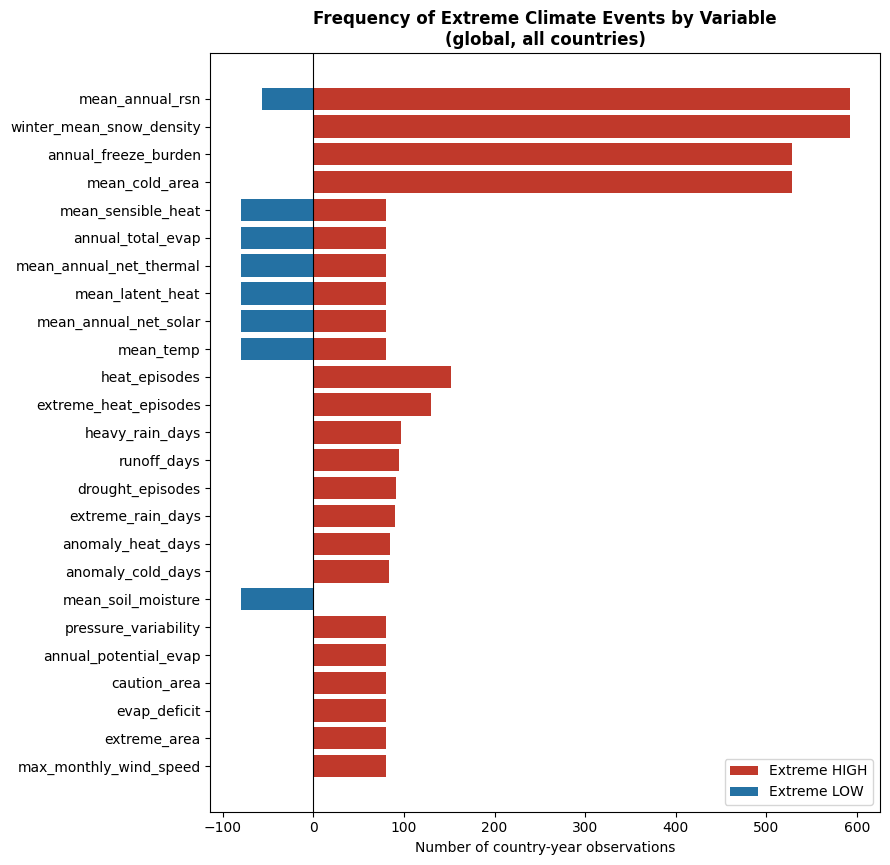

In [ ]:
freq = (extreme_df[extreme_df["is_extreme"]]
        .groupby(["variable", "direction"])["country"]
        .count()
        .unstack(fill_value=0))

if "HIGH" not in freq.columns:
    freq["HIGH"] = 0
if "LOW" not in freq.columns:
    freq["LOW"] = 0

freq["total"] = freq["HIGH"] + freq["LOW"]
freq = freq.sort_values("total", ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(9, max(7, len(freq) * 0.35)))
ax.barh(freq.index, freq.get("HIGH", 0), color=RED, label="Extreme HIGH")
ax.barh(freq.index, -freq.get("LOW", 0),  color=BLUE, label="Extreme LOW")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Number of country-year observations")
ax.set_title("Frequency of Extreme Climate Events by Variable\n(global, all countries)",
                fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(extremes_plots_dir/"extreme_climate_variable_freq.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

In [94]:
def forward_selection_extremes(df_final, extreme_df, health_col, candidates, max_features=4):
    ext_flags = extreme_df[extreme_df['variable'].isin(candidates)].pivot_table(
        index=['country', 'year'], columns='variable', values='is_extreme', aggfunc='max'
    ).fillna(0).astype(int)
    ext_flags.columns = [f"ext_{c.replace('.', '_')}" for c in ext_flags.columns]
    ext_flags = ext_flags.reset_index()

    df_sub = df_final[df_final['cause'] == health_col].copy()
    df_sub = df_sub.merge(ext_flags, on=['country', 'year'], how='left').fillna(0)
    
    all_ext_cols = [c for c in df_sub.columns if c.startswith('ext_')]
    for col in all_ext_cols:
        df_sub[f"{col}_lag1"] = df_sub.groupby('country')[col].shift(1)
    
    df_sub = df_sub.dropna()

    selected = []
    remaining = [c for c in df_sub.columns if c.startswith('ext_')]
    current_score, best_new_score = 0.0, 0.0
    
    print(f"\n SELECTING BEST SHOCKS FOR: {health_col}")
    
    while remaining and len(selected) < max_features:
        scores_with_candidates = []
        for candidate in remaining:
            formula = f"DALYs ~ " + " + ".join(selected + [candidate]) + " + C(country) + C(year)"
            try:
                res = smf.ols(formula, data=df_sub).fit()
                scores_with_candidates.append((res.rsquared_adj, candidate))
            except: continue
        
        if not scores_with_candidates: break
        
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()
        
        if current_score < best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            print(f"   Step {len(selected)}: Added {best_candidate:30s} | Adj.R2: {best_new_score:.4f}")
        else:
            break
    print(f"\nFINAL MODEL FOR {health_col}:")
    final_formula = f"DALYs ~ " + " + ".join(selected) + " + C(country) + C(year)"
    final_model = smf.ols(final_formula, data=df_sub).fit(
        cov_type='cluster', cov_kwds={'groups': df_sub['country']}
    )
    
    res_summary = pd.DataFrame({
        'Coef': final_model.params[selected],
        'P-value': final_model.pvalues[selected]
    })
    res_summary['Sig'] = res_summary['P-value'].apply(lambda x: '***' if x<0.01 else '**' if x<0.05 else '*' if x<0.1 else '')
    print(res_summary)
    return final_model

KEY_VARS = ['annual_freeze_burden', 'anomaly_cold_days', 'anomaly_heat_days', 'mean_cold_area',
            'runoff_days', 'total_tropical_nights', 'mean_temp', 'mean_annual_rsn', 'mean_annual_net_solar',
            'pm25_mean', 'no2_mean', 'ozone_mean']

for h_col in ['Cardiovascular diseases', 'Chronic respiratory diseases', 'Environmental heat and cold exposure']:
    forward_selection_extremes(final_table, extreme_df, h_col, KEY_VARS)


 SELECTING BEST SHOCKS FOR: Cardiovascular diseases
   Step 1: Added ext_mean_cold_area             | Adj.R2: 0.9394
   Step 2: Added ext_mean_cold_area_lag1        | Adj.R2: 0.9396
   Step 3: Added ext_anomaly_heat_days          | Adj.R2: 0.9397
   Step 4: Added ext_anomaly_heat_days_lag1     | Adj.R2: 0.9399

FINAL MODEL FOR Cardiovascular diseases:
                                  Coef   P-value Sig
ext_mean_cold_area          248.010192  0.033559  **
ext_mean_cold_area_lag1     242.092945  0.052550   *
ext_anomaly_heat_days       180.870004  0.237431    
ext_anomaly_heat_days_lag1  176.209325  0.222222    

 SELECTING BEST SHOCKS FOR: Chronic respiratory diseases
   Step 1: Added ext_anomaly_heat_days          | Adj.R2: 0.9285
   Step 2: Added ext_anomaly_heat_days_lag1     | Adj.R2: 0.9288
   Step 3: Added ext_no2_mean_lag1              | Adj.R2: 0.9289
   Step 4: Added ext_mean_annual_net_solar_lag1 | Adj.R2: 0.9290

FINAL MODEL FOR Chronic respiratory diseases:
               

**Cardiovascular:**

The most significant result is ext_mean_cold_area (Area of Extreme Cold). A coefficient of 248.0 means that when a country experiences abnormal cold, DALYs increase by 248 points. The lag is also significant. Heat (anomaly_heat) also adds (+180), but it is less statistically stable.

**Respiratory:**

Here, ext_mean_annual_net_solar_lag1 (Solar radiation with lag) stands out. The negative coefficient (-21.16) confirms that sunny years with low humidity in the past “ease” the condition of the respiratory tract in the future.

**Environmental:**

ext_mean_annual_net_solar_lag1 (Coef: -5.54, p = 0.035): This negative coefficient indicates that extremely high solar radiation in the previous year is associated with a decrease in direct heat/cold-related deaths in the current year.